# Machine Learning – ASHRAE Energy Analysis

## Ziel

Vorhersage des Energieverbrauchs anhand von Gebäude- und Wetterinformationen.

## Forschungsfrage

Wie gut lässt sich der Energieverbrauch anhand von Gebäude- und Wettermerkmalen vorhersagen?

## Methodik

1. Daten laden
2. Datenaufbereitung
3. Feature Engineering
4. Train-Test-Split
5. Random-Forest-Regressionsmodell
6. Modellbewertung
7. Visualisierung der Vorhersagen
8. Analyse der Feature Importance

In [ ]:
%pip install scikit-learn

In [3]:
# Bibliotheken importieren

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import mysql.connector

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [4]:
# Verbindung mit MySQL herstellen

connection = mysql.connector.connect(
    host="localhost",
    user="Dian-Data",
    password="dian_data_2026",
    database="ashrae_energy"
)

print("Verbindung erfolgreich")

Verbindung erfolgreich


In [5]:
# Daten für Machine Learning laden

query_ml = """
SELECT
    meter_reading,
    square_feet,
    year_built,
    floor_count,
    air_temperature,
    cloud_coverage,
    dew_temperature,
    precip_depth_1_hr,
    sea_level_pressure,
    wind_direction,
    wind_speed,
    meter,
    primary_use
FROM ashrae_energy.train_full
WHERE meter_reading IS NOT NULL
ORDER BY RAND()
LIMIT 100000;
"""

df_ml = pd.read_sql(query_ml, connection)

print("Anzahl der Beobachtungen:", len(df_ml))
print("Anzahl der Variablen:", len(df_ml.columns))

df_ml.head()

C:\Users\MamadouDianDiallo\AppData\Local\Temp\ipykernel_31792\3771643824.py:24: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_ml = pd.read_sql(query_ml, connection)


Anzahl der Beobachtungen: 100000
Anzahl der Variablen: 13


,meter_reading,square_feet,year_built,floor_count,air_temperature,cloud_coverage,dew_temperature,precip_depth_1_hr,sea_level_pressure,wind_direction,wind_speed,meter,primary_use
0,80.8444,51471,NaN,NaN,23.3,4.0,21.1,0.0,1015.6,180.0,4.1,0,Office
1,243.2670,278795,NaN,NaN,8.3,0.0,5.6,0.0,1014.1,180.0,3.6,0,Lodging/residential
2,19.5000,30401,NaN,4.0,10.0,NaN,6.1,0.0,1019.2,60.0,2.1,0,Education
3,112.3980,237702,NaN,NaN,18.9,NaN,6.7,0.0,1016.5,120.0,2.6,1,Education
4,23.5510,13091,NaN,NaN,14.4,4.0,11.7,0.0,1013.9,300.0,4.1,0,Manufacturing/industrial


In [ ]:
# Datenqualität prüfen

print("Fehlende Werte:")
print(df_ml.isnull().sum())

print("\nDatentypen:")
print(df_ml.dtypes)

In [7]:
# Datenaufbereitung

# Zielvariable
y = df_ml["meter_reading"]

# Eingangsvariablen
X = df_ml.drop(columns=["meter_reading"])

# Kategorische Variable umwandeln
X = pd.get_dummies(
    X,
    columns=["primary_use"],
    drop_first=True
)

# Fehlende Werte durch den Median ersetzen
X = X.fillna(X.median(numeric_only=True))

# Kontrolle
print("Anzahl der Merkmale:", X.shape[1])
print("Fehlende Werte nach der Aufbereitung:", X.isnull().sum().sum())

Anzahl der Merkmale: 26
Fehlende Werte nach der Aufbereitung: 0


In [8]:
# Daten in Trainings- und Testdaten aufteilen

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Trainingsdaten:", len(X_train))
print("Testdaten:", len(X_test))

Trainingsdaten: 80000
Testdaten: 20000


In [ ]:
# Datenaufbereitung

# Zielvariable
y = df_ml["meter_reading"]

# Eingangsvariablen
X = df_ml.drop(columns=["meter_reading"])

# Kategorische Variable umwandeln
X = pd.get_dummies(
    X,
    columns=["primary_use"],
    drop_first=True
)

# Fehlende Werte durch den Median ersetzen
X = X.fillna(X.median(numeric_only=True))

# Kontrolle
print("Anzahl der Merkmale:", X.shape[1])
print("Fehlende Werte nach der Aufbereitung:", X.isnull().sum().sum())

Anzahl der Merkmale: 26
Fehlende Werte nach der Aufbereitung: 0


In [10]:
# Random-Forest-Modell trainieren

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

model.fit(X_train, y_train)

print("Modell erfolgreich trainiert")

Modell erfolgreich trainiert


In [11]:
# Vorhersagen erstellen

y_pred = model.predict(X_test)

# Modellbewertung
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Modellbewertung")
print("----------------")
print("MAE :", round(mae, 2))
print("RMSE:", round(rmse, 2))
print("R²  :", round(r2, 4))

Modellbewertung
----------------
MAE : 2401.51
RMSE: 138711.72
R²  : -0.1533


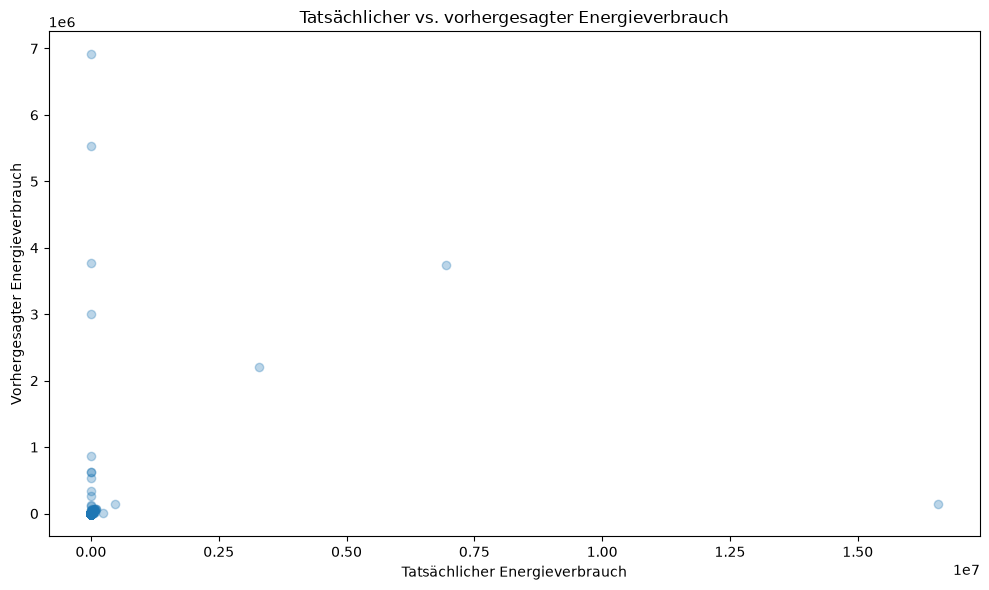

In [12]:
# Tatsächliche und vorhergesagte Werte vergleichen

plt.figure(figsize=(10, 6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.3
)

plt.xlabel("Tatsächlicher Energieverbrauch")
plt.ylabel("Vorhergesagter Energieverbrauch")
plt.title("Tatsächlicher vs. vorhergesagter Energieverbrauch")

plt.tight_layout()
plt.show()

„Das Random-Forest-Modell erreicht auf den Testdaten einen R²-Wert von -0,153. Die Vorhersageleistung ist damit begrenzt.“
„Die starke Streuung des Energieverbrauchs und die unterschiedlichen Gebäudetypen und Zählertypen erschweren die Vorhersage.